In [29]:
import sys
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


In [30]:
# # 01 — EDA & Data Quality

# Allow `import src.*` when run from the project root
ROOT = Path('/Users/tienanh211/Downloads/marketing project/beauty_campaign_analytics')
sys.path.insert(0, str(ROOT))

DB_PATH = ROOT / "data" / "beauty.duckdb"
assert DB_PATH.exists(), f"Run `python src/data_loader.py` first. Missing: {DB_PATH}"

con = duckdb.connect(str(DB_PATH), read_only=True)

print("Full table from DB (first 5 rows):")
print(con.execute("SELECT * FROM campaigns_enriched LIMIT 5").df().to_string(index=False))

# %% [markdown]
# ## 1. Row counts, date ranges, brand mix

# %%
print("Tables & views in DB:")
print(con.execute(
    "SELECT table_name, table_type FROM information_schema.tables "
    "WHERE table_schema='main' ORDER BY table_name"
).df().to_string(index=False))

# %%
overview = con.execute("""
    SELECT
        brand,
        COUNT(*)                              AS n_campaigns,
        MIN(campaign_date)                    AS first_date,
        MAX(campaign_date)                    AS last_date,
        COUNT(DISTINCT campaign_type)         AS n_types,
        COUNT(DISTINCT target_audience)       AS n_audiences,
        COUNT(DISTINCT language)              AS n_languages,
        AVG(roi_reported)                     AS roi_avg,
        AVG(is_loss_making)                   AS loss_share
    FROM campaigns_enriched
    GROUP BY brand
    ORDER BY brand
""").df()
print(overview.to_string(index=False))

# %% [markdown]
# ## 2. ROI formula verification
#
# Test two candidate formulas against the supplied `roi_reported`:
#   - `roi_rev_over_cost`        = Revenue / Acquisition_Cost
#   - `roi_net_over_cost`        = (Revenue - Acquisition_Cost) / Acquisition_Cost
#
# If neither matches, the supplied ROI is either generated independently
# (synthetic noise) or uses a formula involving other columns. Either way
# we must report this and decide which to model.

# %%
roi_check = con.execute("""
    SELECT
        roi_reported,
        roi_rev_over_cost,
        roi_net_over_cost,
        ABS(roi_reported - roi_rev_over_cost) AS diff_rev_over_cost,
        ABS(roi_reported - roi_net_over_cost) AS diff_net_over_cost
    FROM stg_campaigns
    WHERE acquisition_cost > 0
""").df()

print("Median absolute difference vs. roi_reported:")
print(f"  Revenue / Cost        : {roi_check['diff_rev_over_cost'].median():,.2f}")
print(f"  (Revenue - Cost)/Cost : {roi_check['diff_net_over_cost'].median():,.2f}")

corr_rev = roi_check[["roi_reported", "roi_rev_over_cost"]].corr().iloc[0, 1]
corr_net = roi_check[["roi_reported", "roi_net_over_cost"]].corr().iloc[0, 1]
print(f"\nCorrelation with roi_reported:")
print(f"  Revenue / Cost        : {corr_rev:.4f}")
print(f"  (Revenue - Cost)/Cost : {corr_net:.4f}")

# %% [markdown]
# **What to write down here:** which (if any) formula matches. If neither,
# state that `roi_reported` is treated as an *exogenous performance index*
# (likely with injected noise in this synthetic dataset) and that we will
# additionally model `roi_rev_over_cost` as a defensible structural ROI.

# %% [markdown]
# ## 3. Loss-making campaign profile (the headline)

# %%
loss = con.execute("""
    SELECT
        campaign_type,
        target_audience,
        channel_mode,
        COUNT(*)                          AS n,
        AVG(roi_reported)                 AS roi_avg,
        AVG(is_loss_making)               AS loss_share,
        SUM(acquisition_cost)             AS spend
    FROM campaigns_enriched
    GROUP BY 1, 2, 3
    HAVING COUNT(*) >= 50
    ORDER BY loss_share DESC
    LIMIT 15
""").df()
print("\nTop-15 loss-making (campaign_type × audience × channel_mode) cells:")
print(loss.to_string(index=False))

# %% [markdown]
# ## 4. Missingness, duplicates, outliers

# %%
nulls = con.execute("""
    SELECT
        SUM(CASE WHEN campaign_date IS NULL THEN 1 ELSE 0 END) AS null_dates,
        SUM(CASE WHEN impressions <= 0 THEN 1 ELSE 0 END)      AS zero_impressions,
        SUM(CASE WHEN clicks > impressions THEN 1 ELSE 0 END)  AS clicks_exceed_imps,
        SUM(CASE WHEN leads > clicks THEN 1 ELSE 0 END)        AS leads_exceed_clicks,
        SUM(CASE WHEN conversions > leads THEN 1 ELSE 0 END)   AS convs_exceed_leads
    FROM stg_campaigns
""").df()
print("\nFunnel-integrity violations (should all be 0):")
print(nulls.to_string(index=False))

# %%
dupes = con.execute("""
    SELECT brand, COUNT(*) - COUNT(DISTINCT campaign_id) AS duplicate_ids
    FROM stg_campaigns
    GROUP BY brand
""").df()
print("\nDuplicate campaign IDs per brand:")
print(dupes.to_string(index=False))

# %% [markdown]
# ## 5. Time-series & festival-window concentration

# %%
monthly = con.execute("""
    SELECT month_start, brand, n_campaigns, roi_avg, loss_share, festival_window_campaigns
    FROM mart_brand_monthly
    ORDER BY month_start, brand
""").df()
print("\nMonthly brand rollup (first 12 rows):")
print(monthly.head(12).to_string(index=False))

# %%
festival_effect = con.execute("""
    SELECT
        in_festival_window,
        COUNT(*)                        AS n,
        AVG(roi_reported)               AS roi_avg,
        AVG(is_loss_making)             AS loss_share,
        AVG(engagement_score)           AS engagement_avg,
        SUM(revenue)                    AS revenue,
        SUM(acquisition_cost)           AS cost
    FROM campaigns_enriched
    GROUP BY in_festival_window
""").df()
print("\nFestival-window vs non-festival-window:")
print(festival_effect.to_string(index=False))


con.close()

Full table from DB (first 5 rows):
 campaign_id brand campaign_type  target_audience      customer_segment                channel_used language  duration_days campaign_date  impressions  clicks  leads  conversions   revenue  acquisition_cost  roi_reported  engagement_score      ctr  click_to_lead  lead_to_conv  imp_to_conv  revenue_per_conv  conv_rate  roi_rev_over_cost  roi_net_over_cost channel_mode  is_loss_making      dow  is_weekend  month  quarter  year  iso_week   launched_on_festival in_festival_window_name  in_festival_window
TI-CMP-12770  tira           SEO            Youth      Premium Shoppers WhatsApp, Google, Instagram    Hindi             27    2025-02-07        78607    7894   3240         1535  655445.0            102.58          3.16             16.12 0.100424       0.410438      0.473765     0.019528             427.0   0.019528        6389.598362        6388.598362        multi               0   Friday       False      2        1  2025         6                   No

In [31]:
# spearman correlation heatmap 
con = duckdb.connect(str(DB_PATH), read_only=True)
df = con.execute("SELECT * FROM campaigns_enriched").df()
con.close()

numeric_cols = [
    "impressions", "clicks", "leads", "conversions", "revenue",
    "acquisition_cost", "duration_days", "engagement_score", "roi_reported",
]
corr_p = df[numeric_cols].corr(method="pearson")    # linear
corr_s = df[numeric_cols].corr(method="spearman")   # rank-based, monotonic


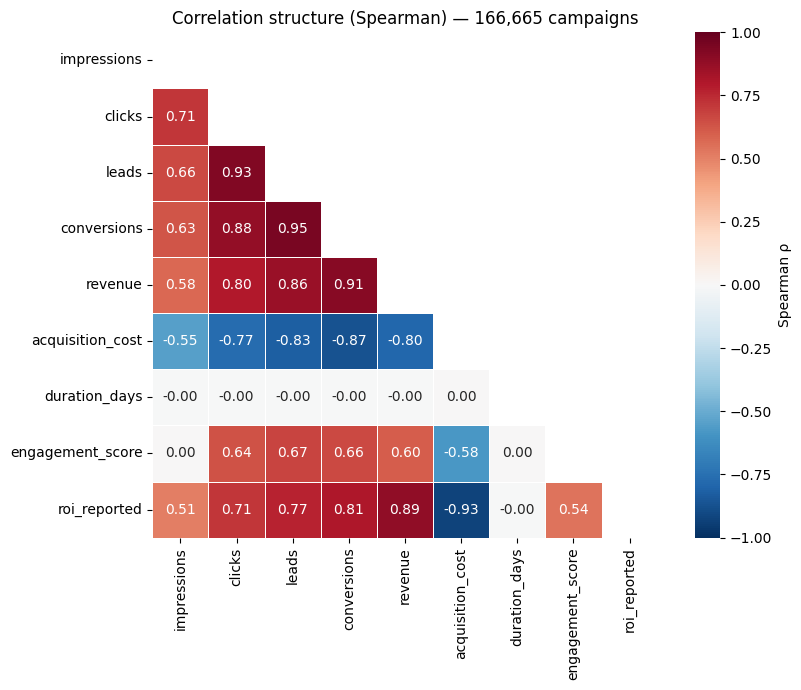

In [32]:
mask = np.triu(np.ones_like(corr_s, dtype=bool))  # hide upper triangle
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_s,
    mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, cbar_kws={"label": "Spearman ρ"},
    ax=ax,
)
ax.set_title("Correlation structure (Spearman) — 166,665 campaigns")
plt.tight_layout()

In [33]:
from helpers import anova_with_effect_size
# ANOVA for campaign-type comparison
con = duckdb.connect(str(DB_PATH), read_only=True)
anova_campaign_type = con.execute("""
    SELECT campaign_type, roi_reported
    FROM campaigns_enriched
""").df()
con.close()
anova_results_campaign_type = anova_with_effect_size(anova_campaign_type, "roi_reported", "campaign_type")
print("ANOVA results for campaign_type:")
print(f"F={anova_results_campaign_type['F']:.4f}, p={anova_results_campaign_type['p']:.4f}, η²={anova_results_campaign_type['eta_sq']:.4f}, Tukey: {anova_results_campaign_type['tukey']}")
# ANOVA for ROI by target_audience
con = duckdb.connect(str(DB_PATH), read_only=True)
anova_audience = con.execute("""
    SELECT target_audience, roi_reported
    FROM campaigns_enriched
""").df()
con.close()
anova_results_audience = anova_with_effect_size(anova_audience, "roi_reported", "target_audience")
print("\nANOVA results for target_audience:")
print(f"F={anova_results_audience['F']:.4f}, p={anova_results_audience['p']:.4f}, η²={anova_results_audience['eta_sq']:.4f}, Tukey: {anova_results_audience['tukey']}")


ANOVA results for campaign_type:
F=1.1152, p=0.3472, η²=0.0000, Tukey:      Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1      group2    meandiff p-adj   lower  upper  reject
-------------------------------------------------------------
     Email   Influencer  -0.0448 0.6958 -0.1392 0.0497  False
     Email     Paid Ads   0.0216 0.9714  -0.073 0.1162  False
     Email          SEO   -0.005 0.9999 -0.0997 0.0896  False
     Email Social Media   0.0148 0.9931 -0.0799 0.1095  False
Influencer     Paid Ads   0.0664 0.3096 -0.0282  0.161  False
Influencer          SEO   0.0397 0.7828 -0.0549 0.1344  False
Influencer Social Media   0.0596 0.4236 -0.0351 0.1543  False
  Paid Ads          SEO  -0.0267   0.94 -0.1215 0.0681  False
  Paid Ads Social Media  -0.0068 0.9997 -0.1016  0.088  False
       SEO Social Media   0.0199 0.9793  -0.075 0.1148  False
-------------------------------------------------------------

ANOVA results for target_audience:
F=0.3907, p=0.8155, η²=0.

In [34]:
# ANOVA for ROI by language
con = duckdb.connect(str(DB_PATH), read_only=True)
anova_language = con.execute("""
    SELECT language, roi_reported
    FROM campaigns_enriched
""").df()
con.close()
anova_results_language = anova_with_effect_size(anova_language, "roi_reported", "language")
print("\nANOVA results for language:")
print(f"F={anova_results_language['F']:.4f}, p={anova_results_language['p']:.4f}, η²={anova_results_language['eta_sq']:.4f}, Tukey: {anova_results_language['tukey']}")

# ANOVA for ROI by brand    
con = duckdb.connect(str(DB_PATH), read_only=True)
anova_brand = con.execute("""
    SELECT brand, roi_reported
    FROM campaigns_enriched
""").df()
con.close()
anova_results_brand = anova_with_effect_size(anova_brand, "roi_reported", "brand")
print("\nANOVA results for brand:")
print(f"F={anova_results_brand['F']:.4f}, p={anova_results_brand['p']:.4f}, η²={anova_results_brand['eta_sq']:.4f}, Tukey: {anova_results_brand['tukey']}")


ANOVA results for language:
F=1.7178, p=0.1609, η²=0.0000, Tukey:  Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
Bengali English   0.0438 0.4928  -0.036 0.1236  False
Bengali   Hindi   0.0639 0.1669 -0.0158 0.1436  False
Bengali   Tamil   0.0575 0.2497 -0.0223 0.1373  False
English   Hindi   0.0201 0.9166 -0.0597 0.0998  False
English   Tamil   0.0137 0.9715 -0.0661 0.0935  False
  Hindi   Tamil  -0.0064 0.9969 -0.0861 0.0733  False
-----------------------------------------------------

ANOVA results for brand:
F=1.1644, p=0.3121, η²=0.0000, Tukey:  Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
  nykaa purplle  -0.0309 0.4841 -0.0939 0.0321  False
  nykaa    tira  -0.0388 0.3181 -0.1019 0.0242  False
purplle    tira   -0.008 0.9529  -0.071 0.0551  False
-----

In [35]:
from typing import Callable
import pandas as pd

TreatmentFn = Callable[[pd.DataFrame], pd.Series]

TREATMENTS: dict[str, TreatmentFn] = {
    "influencer_vs_other": lambda d: (d["campaign_type"] == "Influencer").astype(int),
    "multi_vs_single":     lambda d: (d["channel_mode"] == "multi").astype(int),
    "festival_vs_not":     lambda d: d["in_festival_window"].astype(int),
}
CANONICAL_CONFOUNDERS = [
    "target_audience",     # pre-treatment campaign brief
    "customer_segment",    # pre-treatment
    "language",            # pre-treatment
    "brand",               # pre-treatment
    "duration_days",       # pre-treatment plan
    "log_acq_cost",        # pre-treatment budget
    "in_festival_window",  # pre-treatment calendar — exclude if it's the treatment
]
FORBIDDEN_MEDIATORS = [
    "impressions",         # caused by spend + channel choice
    "clicks", "leads",     # downstream funnel events
    "conversions",         # the numerator of the outcome
    "revenue",             # downstream funnel
    "engagement_score",    # post-launch measurement
    "roi_reported",        # depends on revenue
    "roi_rev_over_cost",   # same
    "ctr", "lead_to_conv", # ratios of mediators
]



In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression, LinearRegression

def build_feature_matrix(df: pd.DataFrame, confounders: list[str]) -> tuple[np.ndarray, list[str]]:
    """One-hot encode categoricals, log-scale cost, z-score numerics."""
    df = df.copy()
    if "log_acq_cost" in confounders and "log_acq_cost" not in df.columns:
        df["log_acq_cost"] = np.log1p(df["acquisition_cost"])

    cat = [c for c in confounders if df[c].dtype == "object" or df[c].dtype == "bool"]
    num = [c for c in confounders if c not in cat]

    X_cat = pd.get_dummies(df[cat].astype(str), drop_first=True)
    X_num = pd.DataFrame(StandardScaler().fit_transform(df[num]), columns=num, index=df.index)
    X = pd.concat([X_num, X_cat.astype(float)], axis=1)
    return X.values.astype(float), list(X.columns)
def cross_fit(X, T, Y, k=5, seed=7,
              propensity_model=None, outcome_model=None,
              clip=(0.01, 0.99)):
    """Return e_hat, mu0, mu1 — all length N — using K-fold cross-fitting."""
    n = len(X)
    e_hat = np.zeros(n); mu0 = np.zeros(n); mu1 = np.zeros(n)
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)

    for tr_idx, te_idx in kf.split(X):
        # ---- propensity ----
        ps = (propensity_model or LogisticRegression(max_iter=1000, C=1.0)).fit(X[tr_idx], T[tr_idx])
        e_hat[te_idx] = ps.predict_proba(X[te_idx])[:, 1]

        # ---- outcome: fit two arms separately, predict on the WHOLE test fold ----
        tr0 = tr_idx[T[tr_idx] == 0]
        tr1 = tr_idx[T[tr_idx] == 1]
        om0 = (outcome_model or LinearRegression()).fit(X[tr0], Y[tr0])
        om1 = (outcome_model or LinearRegression()).fit(X[tr1], Y[tr1])
        mu0[te_idx] = om0.predict(X[te_idx])
        mu1[te_idx] = om1.predict(X[te_idx])

    e_hat = np.clip(e_hat, clip[0], clip[1])
    return e_hat, mu0, mu1
con = duckdb.connect(str(DB_PATH), read_only=True)
df = con.execute("SELECT * FROM campaigns_enriched").df()
con.close()

treatment_name = "influencer_vs_other"
T = TREATMENTS[treatment_name](df).values
Y = df["conv_rate"].values

# Confounder list — drop in_festival_window if it's the treatment
confounders = list(CANONICAL_CONFOUNDERS)
if treatment_name == "festival_vs_not":
    confounders.remove("in_festival_window")


# Build features (note: log_acq_cost was added in Cell 1)
X, feature_names = build_feature_matrix(df, confounders)
print(f"Feature matrix: {X.shape}  ({len(feature_names)} columns)")

# Cross-fit (~30s on this data; reduce k to 3 for faster iteration)
e_hat, mu0, mu1 = cross_fit(X, T, Y, k=5, seed=7)
print(f"\nê(X)   — min={e_hat.min():.3f}  max={e_hat.max():.3f}  mean={e_hat.mean():.3f}")
print(f"μ̂0(X) — mean={mu0.mean():.5f}")
print(f"μ̂1(X) — mean={mu1.mean():.5f}")

# Cache the three nuisance arrays so Phase 4 / 6 don't need to refit.
# CSV by default — switch to .to_parquet(...) if you have pyarrow installed.
NUISANCE_DIR = ROOT / "data"
NUISANCE_DIR.mkdir(exist_ok=True)
pd.DataFrame({"e_hat": e_hat, "mu0": mu0, "mu1": mu1}).to_csv(
    NUISANCE_DIR / f"nuisance_{treatment_name}.csv", index=False
)

Feature matrix: (166665, 16)  (16 columns)

ê(X)   — min=0.180  max=0.222  mean=0.201
μ̂0(X) — mean=0.01867
μ̂1(X) — mean=0.01872


In [37]:
from dataclasses import dataclass
from sklearn.neighbors import NearestNeighbors


@dataclass
class CausalEstimate:
    method: str
    estimand: str          # "ATE", "ATT", or "naive"
    estimate: float
    ci_lo: float = np.nan
    ci_hi: float = np.nan
    n_treated: int = -1
    n_control: int = -1


def naive_diff(T, Y) -> CausalEstimate:
    return CausalEstimate(
        method="Naive diff",
        estimand="naive",
        estimate=float(Y[T == 1].mean() - Y[T == 0].mean()),
        n_treated=int(T.sum()),
        n_control=int((1 - T).sum()),
    )


def matched_att(T, Y, e_hat, caliper: float | None = None) -> CausalEstimate:
    treated_idx = np.where(T == 1)[0]
    control_idx = np.where(T == 0)[0]
    nn = NearestNeighbors(n_neighbors=1).fit(e_hat[control_idx].reshape(-1, 1))
    distances, matches = nn.kneighbors(e_hat[treated_idx].reshape(-1, 1))
    matches = matches.flatten()
    distances = distances.flatten()
    if caliper is not None:
        keep = distances <= caliper
        treated_idx = treated_idx[keep]
        matches = matches[keep]
    matched_control_idx = control_idx[matches]
    att = float((Y[treated_idx] - Y[matched_control_idx]).mean())
    return CausalEstimate(
        method=f"Matched ATT (caliper={caliper})",
        estimand="ATT",
        estimate=att,
        n_treated=len(treated_idx),
        n_control=len(matched_control_idx),
    )


def ipw_ate(T, Y, e_hat) -> CausalEstimate:
    ipw = (T * Y / e_hat) - ((1 - T) * Y / (1 - e_hat))
    return CausalEstimate(
        method="IPW ATE",
        estimand="ATE",
        estimate=float(ipw.mean()),
        n_treated=int(T.sum()),
        n_control=int((1 - T).sum()),
    )


def g_comp_ate(mu0, mu1) -> CausalEstimate:
    return CausalEstimate(
        method="Outcome reg ATE",
        estimand="ATE",
        estimate=float((mu1 - mu0).mean()),
    )


def aipw_ate(T, Y, e_hat, mu0, mu1) -> CausalEstimate:
    """Doubly-robust ATE. Consistent if EITHER propensity OR outcome model is correct."""
    aipw_terms = ((mu1 - mu0)
                  + T * (Y - mu1) / e_hat
                  - (1 - T) * (Y - mu0) / (1 - e_hat))
    return CausalEstimate(
        method="AIPW ATE (headline)",
        estimand="ATE",
        estimate=float(aipw_terms.mean()),
        n_treated=int(T.sum()),
        n_control=int((1 - T).sum()),
    )


def bootstrap_aipw(T, Y, e_hat, mu0, mu1, n_boot: int = 500, seed: int = 7):
    """Fast bootstrap on cached nuisance arrays.

    Note: This resamples the AIPW influence terms without refitting the
    nuisance models per bootstrap. CIs are slightly narrower than the
    "honest" bootstrap that refits inside the loop, but acceptable as a
    first-pass uncertainty quantification.
    """
    rng = np.random.default_rng(seed)
    n = len(T)
    aipw_terms = ((mu1 - mu0)
                  + T * (Y - mu1) / e_hat
                  - (1 - T) * (Y - mu0) / (1 - e_hat))
    samples = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        samples[i] = aipw_terms[idx].mean()
    lo, hi = np.percentile(samples, [2.5, 97.5])
    return float(lo), float(hi)


# Run all five
naive = naive_diff(T, Y)
matched = matched_att(T, Y, e_hat)
ipw = ipw_ate(T, Y, e_hat)
gcomp = g_comp_ate(mu0, mu1)
aipw = aipw_ate(T, Y, e_hat, mu0, mu1)

# Bootstrap CI for AIPW
print("Bootstrapping AIPW (500 iterations)…")
aipw.ci_lo, aipw.ci_hi = bootstrap_aipw(T, Y, e_hat, mu0, mu1, n_boot=500)

results = pd.DataFrame([
    {"method": e.method, "estimand": e.estimand, "estimate": e.estimate,
     "ci_lo": e.ci_lo, "ci_hi": e.ci_hi, "n_t": e.n_treated, "n_c": e.n_control}
    for e in [naive, matched, ipw, gcomp, aipw]
])
print(f"\n=== Treatment: {treatment_name} ===")
print(results.to_string(index=False))

Bootstrapping AIPW (500 iterations)…

=== Treatment: influencer_vs_other ===
                    method estimand  estimate     ci_lo    ci_hi   n_t    n_c
                Naive diff    naive  0.000004       NaN      NaN 33503 133162
Matched ATT (caliper=None)      ATT  0.000020       NaN      NaN 33503  33503
                   IPW ATE      ATE  0.000073       NaN      NaN 33503 133162
           Outcome reg ATE      ATE  0.000053       NaN      NaN    -1     -1
       AIPW ATE (headline)      ATE  0.000056 -0.000039 0.000161 33503 133162


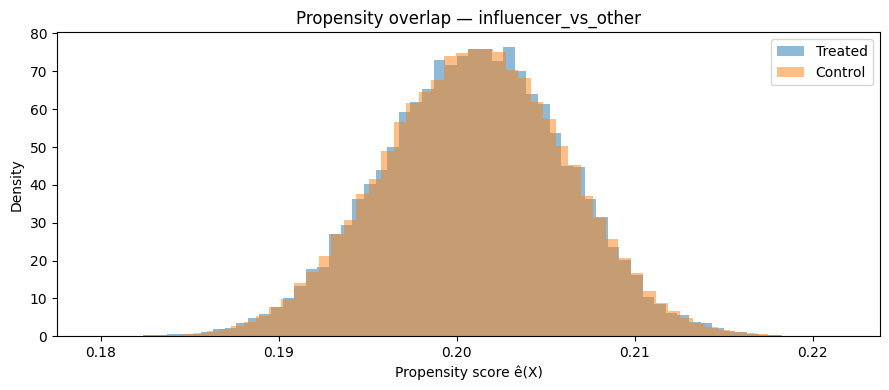

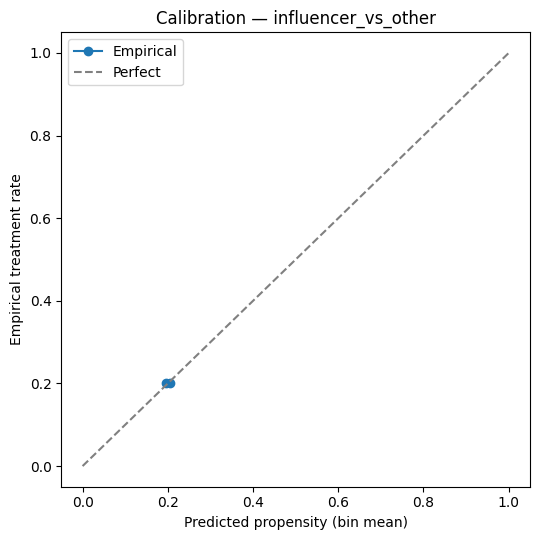


Balance table (top 15 most-imbalanced features) — influencer_vs_other:
                              feature  smd_before  smd_after  abs_improvement
                       language_Hindi   -0.012493  -0.018745        -0.006252
       customer_segment_Working Women   -0.011290  -0.006141         0.005149
                        duration_days   -0.011266  -0.019692        -0.008426
    customer_segment_Premium Shoppers    0.009820   0.004472         0.005349
                     language_English    0.008819   0.010816        -0.001997
                        brand_purplle    0.007549   0.013681        -0.006132
                         log_acq_cost    0.006985   0.007274        -0.000289
target_audience_Tier 2 City Customers    0.006282   0.002905         0.003377
              in_festival_window_True   -0.006217  -0.009607        -0.003390
        target_audience_Working Women    0.006026   0.010512        -0.004486
                           brand_tira   -0.004889  -0.004055         0

In [38]:
def propensity_overlap_plot(T, e_hat, treatment_name, save_dir=None):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(e_hat[T == 1], bins=60, alpha=0.5, density=True, label="Treated")
    ax.hist(e_hat[T == 0], bins=60, alpha=0.5, density=True, label="Control")
    ax.set_xlabel("Propensity score ê(X)")
    ax.set_ylabel("Density")
    ax.set_title(f"Propensity overlap — {treatment_name}")
    ax.legend()
    plt.tight_layout()
    if save_dir is not None:
        save_dir = Path(save_dir); save_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_dir / f"overlap_{treatment_name}.png", dpi=150, bbox_inches="tight")
    return fig


def calibration_plot(T, e_hat, treatment_name, n_bins=10, save_dir=None):
    bins = np.linspace(0, 1, n_bins + 1)
    cal = (pd.DataFrame({"e": e_hat, "T": T})
             .assign(bin=lambda d: pd.cut(d["e"], bins, include_lowest=True))
             .groupby("bin", observed=True)
             .agg(mean_e=("e", "mean"), mean_T=("T", "mean"))
             .dropna())
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.plot(cal["mean_e"], cal["mean_T"], "o-", label="Empirical")
    ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect")
    ax.set_xlabel("Predicted propensity (bin mean)")
    ax.set_ylabel("Empirical treatment rate")
    ax.set_title(f"Calibration — {treatment_name}")
    ax.legend()
    plt.tight_layout()
    if save_dir is not None:
        save_dir = Path(save_dir); save_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_dir / f"calibration_{treatment_name}.png", dpi=150, bbox_inches="tight")
    return fig


def balance_table(X, T, e_hat, feature_names, caliper=None):
    """SMD before vs after nearest-neighbor matching on propensity."""
    def smd(a, b):
        pooled = np.sqrt((a.var() + b.var()) / 2)
        return (a.mean() - b.mean()) / pooled if pooled > 0 else 0.0

    treated_idx = np.where(T == 1)[0]
    control_idx = np.where(T == 0)[0]
    nn = NearestNeighbors(n_neighbors=1).fit(e_hat[control_idx].reshape(-1, 1))
    distances, matches = nn.kneighbors(e_hat[treated_idx].reshape(-1, 1))
    matches = matches.flatten()
    if caliper is not None:
        keep = distances.flatten() <= caliper
        treated_idx = treated_idx[keep]
        matches = matches[keep]
    matched_control_idx = control_idx[matches]

    rows = []
    for i, name in enumerate(feature_names):
        before = smd(X[T == 1, i], X[T == 0, i])
        after = smd(X[treated_idx, i], X[matched_control_idx, i])
        rows.append({"feature": name,
                     "smd_before": before,
                     "smd_after": after,
                     "abs_improvement": abs(before) - abs(after)})
    return (pd.DataFrame(rows)
              .sort_values("smd_before", key=lambda s: s.abs(), ascending=False)
              .reset_index(drop=True))


FIG_DIR = ROOT / "reports" / "figures"

propensity_overlap_plot(T, e_hat, treatment_name, save_dir=FIG_DIR)
plt.show()

calibration_plot(T, e_hat, treatment_name, save_dir=FIG_DIR)
plt.show()

balance = balance_table(X, T, e_hat, feature_names)
print(f"\nBalance table (top 15 most-imbalanced features) — {treatment_name}:")
print(balance.head(15).to_string(index=False))
print(f"\nAfter matching, |SMD| < 0.1 in {(balance['smd_after'].abs() < 0.1).mean():.1%} of features")

In [39]:
def caliper_sweep(T, Y, e_hat, calipers=(None, 0.10, 0.05, 0.01, 0.005)):
    rows = []
    for cal in calipers:
        est = matched_att(T, Y, e_hat, caliper=cal)
        rows.append({"caliper": str(cal),
                     "matched_att": est.estimate,
                     "n_pairs": est.n_treated})
    return pd.DataFrame(rows)


def placebo_test(X, Y, k=5, n_placebo=3, seed=7):
    """Shuffle treatment labels and re-run AIPW. ATE should be ≈ 0."""
    rng = np.random.default_rng(seed)
    n = len(Y)
    half = n // 2
    placebo_estimates = []
    for i in range(n_placebo):
        T_pl = np.zeros(n, dtype=int)
        treated_pos = rng.choice(n, size=half, replace=False)
        T_pl[treated_pos] = 1
        eh, m0, m1 = cross_fit(X, T_pl, Y, k=k, seed=seed + i)
        est = aipw_ate(T_pl, Y, eh, m0, m1)
        placebo_estimates.append(est.estimate)
        print(f"  placebo run {i+1}: ATE = {est.estimate:+.6f}")
    return placebo_estimates


def e_value(rr: float) -> float:
    """E-value for an estimated risk ratio (VanderWeele & Ding, 2017)."""
    if rr < 1:
        rr = 1 / rr
    return rr + (rr * (rr - 1)) ** 0.5


print(f"\n--- Sensitivity 1: caliper sweep ---")
sweep = caliper_sweep(T, Y, e_hat)
print(sweep.to_string(index=False))

print(f"\n--- Sensitivity 2: placebo test (random T) ---")
print("Each ATE below should be near 0 if the pipeline is unbiased.")
placebos = placebo_test(X, Y, k=3, n_placebo=2)  # k=3 + n=2 to keep this <2 min

# E-value example for the AIPW estimate, on the risk-ratio scale.
# For a conversion-rate outcome, RR ≈ (mean_Y_treated / mean_Y_control).
# This rough conversion is for illustration; for a primary report use the
# absolute-difference version (causal_utils.e_value already in your repo).
rr_proxy = (Y[T == 1].mean() / max(Y[T == 0].mean(), 1e-9))
print(f"\n--- Sensitivity 3: E-value ---")
print(f"Naive RR proxy = {rr_proxy:.4f}")
print(f"E-value        = {e_value(rr_proxy):.2f}")
print("→ An unmeasured confounder would need RR ≥ this value with both T and Y to nullify.")


--- Sensitivity 1: caliper sweep ---
caliper  matched_att  n_pairs
   None      0.00002    33503
    0.1      0.00002    33503
   0.05      0.00002    33503
   0.01      0.00002    33503
  0.005      0.00002    33503

--- Sensitivity 2: placebo test (random T) ---
Each ATE below should be near 0 if the pipeline is unbiased.
  placebo run 1: ATE = -0.000041
  placebo run 2: ATE = -0.000020

--- Sensitivity 3: E-value ---
Naive RR proxy = 1.0002
E-value        = 1.01
→ An unmeasured confounder would need RR ≥ this value with both T and Y to nullify.


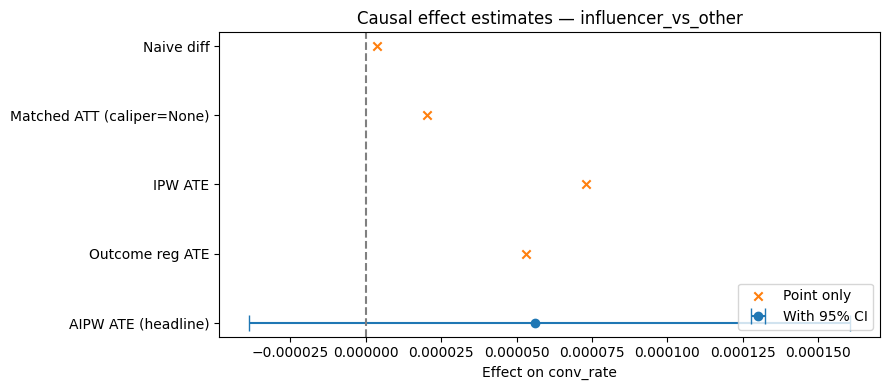


Wrote /Users/tienanh211/Downloads/marketing project/beauty_campaign_analytics/reports/causal_findings_influencer_vs_other.md


In [40]:
def forest_plot(results: pd.DataFrame, treatment_name: str, save_dir=None):
    """Five-row forest plot. Estimates without CIs are drawn as dots only."""
    fig, ax = plt.subplots(figsize=(9, 4))
    y = np.arange(len(results))
    has_ci = results["ci_lo"].notna() & results["ci_hi"].notna()
    if has_ci.any():
        rsub = results[has_ci]
        ysub = y[has_ci.values]
        xerr = [rsub["estimate"] - rsub["ci_lo"], rsub["ci_hi"] - rsub["estimate"]]
        ax.errorbar(rsub["estimate"], ysub, xerr=xerr,
                    fmt="o", capsize=6, color="C0", label="With 95% CI")
    if (~has_ci).any():
        rsub = results[~has_ci]
        ysub = y[(~has_ci).values]
        ax.scatter(rsub["estimate"], ysub, marker="x", color="C1", label="Point only")
    ax.axvline(0, color="gray", linestyle="--")
    ax.set_yticks(y)
    ax.set_yticklabels(results["method"])
    ax.invert_yaxis()
    ax.set_xlabel("Effect on conv_rate")
    ax.set_title(f"Causal effect estimates — {treatment_name}")
    ax.legend(loc="lower right")
    plt.tight_layout()
    if save_dir is not None:
        save_dir = Path(save_dir); save_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_dir / f"forest_{treatment_name}.png", dpi=150, bbox_inches="tight")
    return fig


forest_plot(results, treatment_name, save_dir=FIG_DIR)
plt.show()

# Write findings to markdown — one file per treatment
findings_path = ROOT / "reports" / f"causal_findings_{treatment_name}.md"
findings_path.parent.mkdir(parents=True, exist_ok=True)
with open(findings_path, "w") as f:
    f.write(f"# Causal findings — {treatment_name}\n\n")
    f.write(f"**Outcome:** `conv_rate` (= conversions / impressions)\n")
    f.write(f"**Treatment:** as defined by `TREATMENTS['{treatment_name}']`\n")
    f.write(f"**Confounders:** {', '.join(confounders)}\n")
    f.write(f"**Forbidden mediators:** {', '.join(FORBIDDEN_MEDIATORS)}\n\n")
    f.write("## Results\n\n")
    f.write(results.to_markdown(index=False))
    f.write("\n\n## Sensitivity — caliper sweep\n\n")
    f.write(sweep.to_markdown(index=False))
    f.write(f"\n\n## Sensitivity — placebo runs\n\n")
    for i, p in enumerate(placebos, 1):
        f.write(f"- Run {i}: ATE = {p:+.6f}\n")
    f.write("\n## Caveats\n\n")
    f.write("- Observational data — estimates assume no unmeasured confounders.\n")
    f.write("- Synthetic dataset; effects are expected to be near zero.\n")
    f.write("- AIPW CIs use the fast bootstrap (no per-iteration refit).\n")
print(f"\nWrote {findings_path}")